# Conformal pillbox impedance validation

This notebook compares the new point-based conformal STL material discretization
against the existing legacy geometry pipeline for the 007 cavity geometry.

The geometry is kept identical in all runs:

- `007_vacuum_cavity.stl` → vacuum
- `007_lossymetal_shell.stl` → PEC
- background → PEC


Four simulations are performed:

1. **legacy + `voxelize_rectilinear`**
2. **conformal + `voxelize_rectilinear`**
3. **conformal + `interior_points`**
4. **conformal + `implicit_distance`**

The results are shown in two separate comparisons:

- **Legacy vs. conformal** using the same `voxelize_rectilinear` geometry method.
- **Conformal method comparison** using the three supported PyVista
  inside/outside classification methods.

No analytical resonance reference is used because the cavity is not an ideal
pillbox: the pipe-to-cavity transitions are rounded.

In [1]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.signal import find_peaks

from wakis import GridFIT3D, SolverFIT3D, WakeSolver

In [2]:
def find_repo_root(start=None):
    """Find the WAKIS repository root from the current working directory."""
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "wakis").exists() and (candidate / "tests").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the WAKIS repository root. "
        "Run this notebook from inside the cloned WAKIS repository."
    )


repo_root = find_repo_root()
print("Repository root:", repo_root)

Repository root: /Users/hannesschreiber/Documents/WAKIS


## Geometry and simulation parameters

The numerical parameters below follow the existing 007 / 013 regression setup
closely so that the comparison remains representative of the current WAKIS tests.

`wakelength = 10 m` is intentionally retained because the purpose here is to
compare the impedance spectra and resonance positions. For quick development
checks it can temporarily be reduced.

In [4]:
# ------------------------------------------------------------------
# STL geometry
# ------------------------------------------------------------------
solid_cavity = repo_root / "tests" / "stl" / "007_vacuum_cavity.stl"
solid_shell = repo_root / "tests" / "stl" / "007_lossymetal_shell.stl"

stl_solids = {
    "cavity": str(solid_cavity),
    "shell": str(solid_shell),
}

# Keep the shell explicitly although the background is also PEC.
stl_materials = {
    "cavity": "vacuum",
    "shell": "pec",
}

solids = pv.read(str(solid_cavity)) + pv.read(str(solid_shell))
xmin, xmax, ymin, ymax, zmin, zmax = solids.bounds

# ------------------------------------------------------------------
# Mesh
# ------------------------------------------------------------------
Nx = 30
Ny = 30
Nz = 60

# ------------------------------------------------------------------
# Beam / wake parameters
# ------------------------------------------------------------------
sigmaz = 10e-2       # [m]
q = 1e-9             # [C]
beta = 1.0
xsource = 0.0
ysource = 0.0
xtest = 0.0
ytest = 0.0

wakelength = 10.0    # [m]
skip_cells = 20

# ------------------------------------------------------------------
# Boundary conditions
# ------------------------------------------------------------------
bc_low = ["pec", "pec", "pec"]
bc_high = ["pec", "pec", "pec"]

print("Geometry bounds:")
print(f"x: [{xmin:.6g}, {xmax:.6g}] m")
print(f"y: [{ymin:.6g}, {ymax:.6g}] m")
print(f"z: [{zmin:.6g}, {zmax:.6g}] m")
print(f"Grid: {Nx} x {Ny} x {Nz}")

Geometry bounds:
x: [-0.26, 0.26] m
y: [-0.26, 0.26] m
z: [-0.25, 0.55] m
Grid: 30 x 30 x 60


## Simulation helper

Each case gets its own result directory so the generated `Ez.h5` files do not
overwrite each other. The temporary results are stored below
`notebooks/_008_results/`.

These files should normally **not** be committed to Git.

In [5]:
results_root = repo_root / "notebooks" / "_008_results"
results_root.mkdir(parents=True, exist_ok=True)


def _frequency_axis(wake):
    """Return the impedance frequency axis using the available WakeSolver attribute."""
    for name in ("f", "freq", "frequency"):
        if hasattr(wake, name):
            return np.asarray(getattr(wake, name))
    raise AttributeError(
        "Could not find the WakeSolver frequency axis. "
        "Expected one of: wake.f, wake.freq, wake.frequency."
    )


def run_case(name, geometry_mode, stl_method, clean_results=True):
    print()
    print("=" * 78)
    print(f"Running case: {name}")
    print(f"geometry_mode = {geometry_mode}")
    print(f"stl_method    = {stl_method}")
    print("=" * 78)

    case_folder = results_root / name

    if clean_results and case_folder.exists():
        shutil.rmtree(case_folder)

    case_folder.mkdir(parents=True, exist_ok=True)

    grid = GridFIT3D(
        xmin,
        xmax,
        ymin,
        ymax,
        zmin,
        zmax,
        Nx,
        Ny,
        Nz,
        stl_solids=stl_solids,
        stl_materials=stl_materials,
        stl_method=stl_method,
        geometry_mode=geometry_mode,
        subpixel_smoothing=False,
        stl_scale=1.0,
        stl_rotate=[0, 0, 0],
        stl_translate=[0, 0, 0],
        verbose=1,
    )

    wake = WakeSolver(
        q=q,
        sigmaz=sigmaz,
        beta=beta,
        xsource=xsource,
        ysource=ysource,
        xtest=xtest,
        ytest=ytest,
        skip_cells=skip_cells,
        results_folder=str(case_folder) + "/",
        Ez_file=str(case_folder / "Ez.h5"),
    )

    solver = SolverFIT3D(
        grid,
        wake,
        bc_low=bc_low,
        bc_high=bc_high,
        use_stl=True,
        bg="pec",
        use_gpu=False,
    )

    solver.wakesolve(wakelength=wakelength)

    f = _frequency_axis(wake)
    Z = np.asarray(wake.Z)

    result = {
        "name": name,
        "geometry_mode": geometry_mode,
        "stl_method": stl_method,
        "grid": grid,
        "wake": wake,
        "solver": solver,
        "f": f,
        "Z": Z,
        "Zabs": np.abs(Z),
    }

    # Geometry diagnostics
    for key in stl_solids:
        cell_count = int(np.sum(np.asarray(grid.grid[key]).astype(bool)))

        if geometry_mode == "conformal":
            primal_count = int(np.sum(grid.primal_point_masks[key]))
            dual_count = int(np.sum(grid.dual_point_masks[key]))

            print(
                f"{key:>8s}: "
                f"{primal_count} primal points, "
                f"{cell_count} cell centers, "
                f"{dual_count} dual points"
            )
        else:
            print(f"{key:>8s}: {cell_count} legacy cells")

    return result

## Run the four cases

The conformal `voxelize_rectilinear` result is reused in both later comparisons,
so only four simulations are required.

In [6]:
cases = {}

cases["legacy_voxelize"] = run_case(
    name="legacy_voxelize",
    geometry_mode="legacy",
    stl_method="voxelize_rectilinear",
)

cases["conformal_voxelize"] = run_case(
    name="conformal_voxelize",
    geometry_mode="conformal",
    stl_method="voxelize_rectilinear",
)

cases["conformal_interior"] = run_case(
    name="conformal_interior",
    geometry_mode="conformal",
    stl_method="interior_points",
)

cases["conformal_implicit"] = run_case(
    name="conformal_implicit",
    geometry_mode="conformal",
    stl_method="implicit_distance",
)


Running case: legacy_voxelize
geometry_mode = legacy
stl_method    = voxelize_rectilinear
Generating grid with 54000 mesh cells...
Importing STL solids...
 * Marking cells inside STL solid 'cavity'...
    * STL solid cavity: 12936 cells marked inside the solid.
 * Marking cells inside STL solid 'shell'...
    * STL solid shell: 6603 cells marked inside the solid.
Total grid initialization time: 0.5946638584136963 s
Initializing Wakefield parameters...
Total solver initialization time: 0.00013518333435058594 s
Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=0.9993081933333331 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 7.1290774567883135 S/m
Calculating maximal stable timestep...
    * Simulation timestep: dt=1.505e-11 s
    * Total simulation time for wakelength=1.0 m: tmax=8.811e-09 s
    * Total number of timesteps for wakelength=1.0 m: Nt=585
Pre-computing...


100%|██████████| 2580/2580 [00:10<00:00, 257.14it/s]


Reading h5 file /Users/hannesschreiber/Documents/WAKIS/notebooks/_008_results/legacy_voxelize/Ez.h5
Size of the h5 file: 0.01 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 21654/21654 [00:04<00:00, 4360.52it/s]


Elapsed time 4.966817140579224 s
Calculating transverse wake potential WPx, WPy...


...

Reading h5 file /Users/hannesschreiber/Documents/WAKIS/notebooks/_008_results/conformal_implicit/Ez.h5
Size of the h5 file: 0.01 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 21654/21654 [00:04<00:00, 4547.37it/s]


Elapsed time 4.76236891746521 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 21654/21654 [00:00<00:00, 140983.80it/s]


Elapsed time 0.15412306785583496 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 5s
  cavity: 12973 primal points, 12328 cell centers, 12360 dual points
   shell: 6669 primal points, 5313 cell centers, 5385 dual points


## Comparison 1 — Legacy vs. conformal

Both simulations use **exactly the same**
`stl_method="voxelize_rectilinear"`.

This isolates the effect of changing the geometry/material representation from
the legacy cell-based pipeline to the new point-based conformal pipeline.

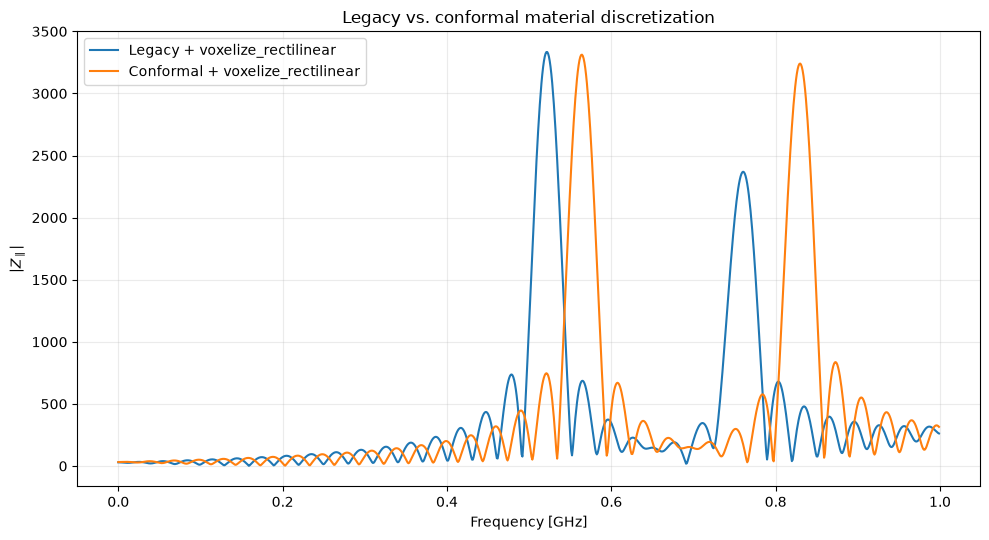

In [8]:
legacy = cases["legacy_voxelize"]
conformal = cases["conformal_voxelize"]

plt.figure(figsize=(10, 5.5))

plt.plot(
    legacy["f"] / 1e9,
    legacy["Zabs"],
    label="Legacy + voxelize_rectilinear",
)

plt.plot(
    conformal["f"] / 1e9,
    conformal["Zabs"],
    label="Conformal + voxelize_rectilinear",
)

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$|Z_\parallel|$")
plt.title("Legacy vs. conformal material discretization")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Comparison 2 — Conformal PyVista methods

This comparison keeps `geometry_mode="conformal"` fixed and changes only the
PyVista inside/outside classification method.

The purpose is to determine how sensitive the new conformal result is to the
underlying STL classification algorithm.

In [ ]:
plt.figure(figsize=(10, 5.5))

for key, label in [
    ("conformal_voxelize", "voxelize_rectilinear"),
    ("conformal_interior", "interior_points"),
    ("conformal_implicit", "implicit_distance"),
]:
    result = cases[key]

    plt.plot(
        result["f"] / 1e9,
        result["Zabs"],
        label=label,
    )

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$|Z_\parallel|$")
plt.title("Conformal geometry: PyVista method comparison")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compare the first detected peaks of the three conformal methods.

conformal_peak_data = {}

for key in (
    "conformal_voxelize",
    "conformal_interior",
    "conformal_implicit",
):
    fp, _ = dominant_peaks(cases[key])
    conformal_peak_data[key] = fp

n_compare = min(len(v) for v in conformal_peak_data.values())

print("Conformal peak positions")
print("------------------------")

for n in range(n_compare):
    fv = conformal_peak_data["conformal_voxelize"][n]
    fi = conformal_peak_data["conformal_interior"][n]
    fd = conformal_peak_data["conformal_implicit"][n]

    print(
        f"peak {n + 1:2d}: "
        f"voxelize = {fv / 1e9:9.6f} GHz, "
        f"interior = {fi / 1e9:9.6f} GHz "
        f"({(fi - fv) / 1e6:+8.3f} MHz), "
        f"implicit = {fd / 1e9:9.6f} GHz "
        f"({(fd - fv) / 1e6:+8.3f} MHz)"
    )

## Interpretation

The two comparisons answer different questions:

### Legacy vs. conformal with identical voxelization

Any difference here comes from the new point-based geometry/material
discretization rather than from changing the PyVista STL classification method.

### Conformal PyVista comparison

Differences between the three conformal curves quantify the sensitivity of the
new discretization to the underlying inside/outside classification method.

Because the cavity has rounded pipe-to-cavity transitions, no simple analytical
pillbox resonance formula is used as a reference in this notebook.